In [1]:
from src.split_data import run_split
from src.eda import run_eda
from src.preprocess import run_preprocess
from src.data_loader import get_loaders
from src.model import run_model
from src.train import run_training
from src.evaluate import run_evaluation

import mlflow

d:\Amikom\semester 6\proyek data mining\tomato_diseases\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def main():
    # main.py — ganti tracking URI dari file:// ke sqlite
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("tomato-disease-classification")

    # 1. Split Data
    print("\n+-------------------------------------+")
    print("|   !!! RUNNING : Proses Split Data   |")
    print("+-------------------------------------+\n")

    run_split()

    # 2. Exploratory Data Analysis
    print("\n+----------------------------------------------------+")
    print("|   !!! RUNNING : Proses Exploratory Data Analysis   |")
    print("+----------------------------------------------------+\n")

    df_valid, eda_results = run_eda()

    # 3. Preprocessing
    print("\n+---------------------------------+")
    print("|   !!! RUNNING : Preprocessing   |")
    print("+---------------------------------+\n")

    train_transform, val_transform = run_preprocess(eda_results)

    # 5. Load data
    print("\n+-----------------------------+")
    print("|   !!! RUNNING : Load Data   |")
    print("+-----------------------------+\n")

    train_loader, val_loader, train_ds, val_ds, train_ds.classes, class_weights = get_loaders()

    print(f"\n Class: {train_ds.classes}\n")
    print(f" Batch Training: {len(train_loader)}")
    print(f" Batch Validasi: {len(val_loader)}\n")
    print(f" Train: {len(train_ds)}")
    print(f" Validasi: {len(val_ds)}")

    # 6. Build Model
    print("\n+-------------------------------+")
    print("|   !!! RUNNING : Build Model   |")
    print("+-------------------------------+\n")

    model, optimizer, criterion, device = run_model(
        class_weights = class_weights 
    )

    # 7. Train Model
    print("\n+-------------------------------+")
    print("|   !!! RUNNING : Train Model   |")
    print("+-------------------------------+\n")

    run_training()

    # 8. Evaluation 
    print("\n+-----------------------------------+")
    print("|   !!! RUNNING : Model Evaluation  |")
    print("+-----------------------------------+\n")

    run_evaluation()


+-------------------------------------+
|   !!! RUNNING : Proses Split Data   |
+-------------------------------------+



Copying files: 16012 files [00:22, 727.40 files/s]


 split sukses : data/processed

+----------------------------------------------------+
|   !!! RUNNING : Proses Exploratory Data Analysis   |
+----------------------------------------------------+


 1. DISTRIBUSI & BALANCE DATASET

  Tomato_Bacterial_spot                              : 2127 gambar
  Tomato_Early_blight                                : 1000 gambar
  Tomato_Late_blight                                 : 1901 gambar
  Tomato_Leaf_Mold                                   : 952 gambar
  Tomato_Septoria_leaf_spot                          : 1771 gambar
  Tomato_Spider_mites_Two_spotted_spider_mite        : 1676 gambar
  Tomato__Target_Spot                                : 1404 gambar
  Tomato__Tomato_YellowLeaf__Curl_Virus              : 3208 gambar
  Tomato__Tomato_mosaic_virus                        : 373 gambar
  Tomato_healthy                                     : 1585 gambar

  Imbalance Ratio (max/min): 8.60


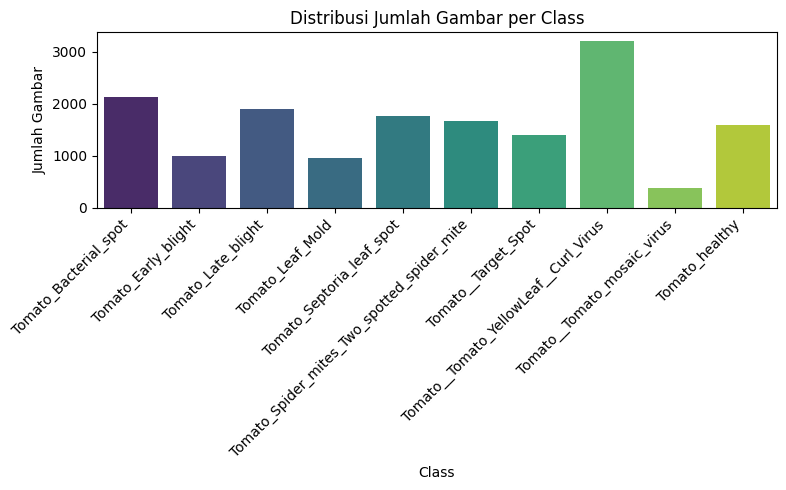


 2. VARIASI RESOLUSI GAMBAR

  Total variasi resolusi : 1
  Resolusi Gambar        : 256x256 px  (15997 gambar)

 3. DETEKSI FILE DUPLIKAT

  Gambar Duplikat : 14

 4. VARIASI FORMAT FILE

  .jpg        : 15996 file
  .jpeg       : 1 file

 7. ANALISIS KECERAHAN GAMBAR

  Rata-rata Kecerahan : 115.84  (0=gelap, 255=terang)
  Min / Max           : 8.25 / 194.56


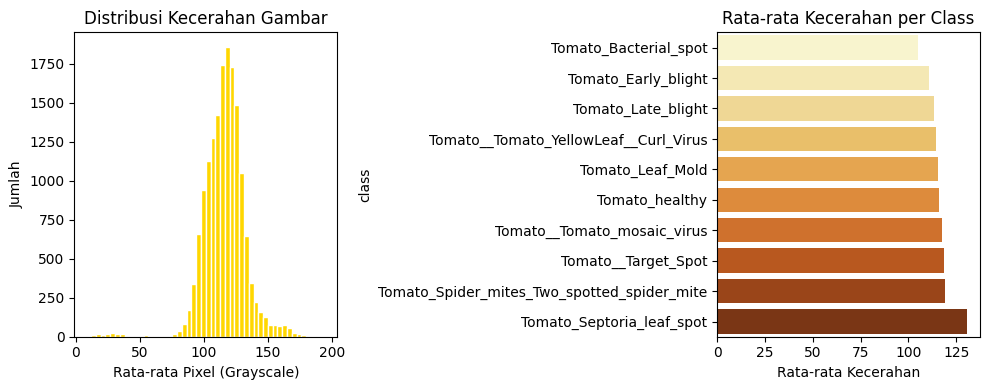

 RINGKASAN HASIL EDA

  Total gambar valid         : 15997
  File rusak / tidak terbaca : 1
  Duplikat terdeteksi        : 14
  Variasi resolusi unik      : 1
  Variasi format file        : ['jpg', 'jpeg']
  Variasi mode warna         : ['RGB']
  Imbalance ratio            : 8.60

+---------------------------------+
|   !!! RUNNING : Preprocessing   |
+---------------------------------+

 Total file dihapus dari train/val : 14
 file .jpeg diubah ke .jpg         : 0 

+-----------------------------+
|   !!! RUNNING : Load Data   |
+-----------------------------+

  -Tomato_Bacterial_spot                                   :  1701 gambar  ->  bobot: 0.7521
  -Tomato_Early_blight                                     :   800 gambar  ->  bobot: 1.5991
  -Tomato_Late_blight                                      :  1521 gambar  ->  bobot: 0.8411
  -Tomato_Leaf_Mold                                        :   761 gambar  ->  bobot: 1.6811
  -Tomato_Septoria_leaf_spot                               

  Train:   0%|          | 0/200 [00:00<?, ?it/s]d:\Amikom\semester 6\proyek data mining\tomato_diseases\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Train  ->  Loss : 0.4105  |  Accuracy : 82.03%
  Val    ->  Loss : 0.2213  |  Accuracy : 94.36%
  Model terbaik disimpan (val_acc : 94.36%)

  Epoch 2/10  LR: 0.000976


  Train  ->  Loss : 0.1264  |  Accuracy : 94.75%
  Val    ->  Loss : 0.1253  |  Accuracy : 96.49%
  Model terbaik disimpan (val_acc : 96.49%)

  Epoch 3/10  LR: 0.000905


  Train  ->  Loss : 0.0909  |  Accuracy : 96.14%
  Val    ->  Loss : 0.0858  |  Accuracy : 97.24%
  Model terbaik disimpan (val_acc : 97.24%)

  Epoch 4/10  LR: 0.000794


...

  Train  ->  Loss : 0.0272  |  Accuracy : 98.81%
  Val    ->  Loss : 0.0442  |  Accuracy : 98.56%
  Model terbaik disimpan (val_acc : 98.56%)

  Epoch 7/10  LR: 0.000346


  Train  ->  Loss : 0.0272  |  Accuracy : 98.84%
  Val    ->  Loss : 0.0315  |  Accuracy : 98.93%
  Model terbaik disimpan (val_acc : 98.93%)

  Epoch 8/10  LR: 0.000207


  Train  ->  Loss : 0.0182  |  Accuracy : 99.18%
  Val    ->  Loss : 0.0241  |  Accuracy : 99.19%
  Model terbaik disimpan (val_acc : 99.19%)

  Epoch 9/10  LR: 0.000096


  Train  ->  Loss : 0.0146  |  Accuracy : 99.42%
  Val    ->  Loss : 0.0255  |  Accuracy : 99.25%
  Model terbaik disimpan (val_acc : 99.25%)

  Epoch 10/10  LR: 0.000025


  Train  ->  Loss : 0.0116  |  Accuracy : 99.46%
  Val    ->  Loss : 0.0245  |  Accuracy : 99.19%

  Training Done
  ------------------------
  Duration : 60.23 minutes
  Best Val Accuracy : 99.25%


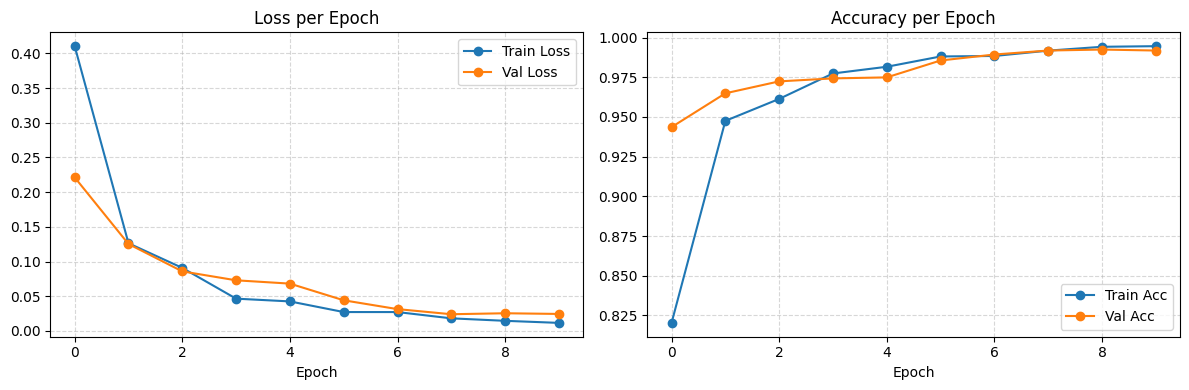

2026/04/27 14:26:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/27 14:26:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


  Kurva disimpan : img/training_curve.png

  MLflow run selesai

+-----------------------------------+
|   !!! RUNNING : Model Evaluation  |
+-----------------------------------+



  Evaluasi: 100%|██████████| 25/25 [00:26<00:00,  1.04s/it]



  Accuracy   : 99.25%
  Macro F1   : 99.16%

  Classification Report:
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       1.00      1.00      1.00       212
                        Tomato_Early_blight       0.95      0.98      0.97       100
                         Tomato_Late_blight       1.00      0.97      0.99       189
                           Tomato_Leaf_Mold       1.00      1.00      1.00        95
                  Tomato_Septoria_leaf_spot       0.99      0.99      0.99       177
Tomato_Spider_mites_Two_spotted_spider_mite       1.00      0.99      1.00       167
                        Tomato__Target_Spot       0.98      0.99      0.98       140
      Tomato__Tomato_YellowLeaf__Curl_Virus       1.00      1.00      1.00       320
                Tomato__Tomato_mosaic_virus       1.00      1.00      1.00        37
                             Tomato_healthy       0.99      1.00      1.00    

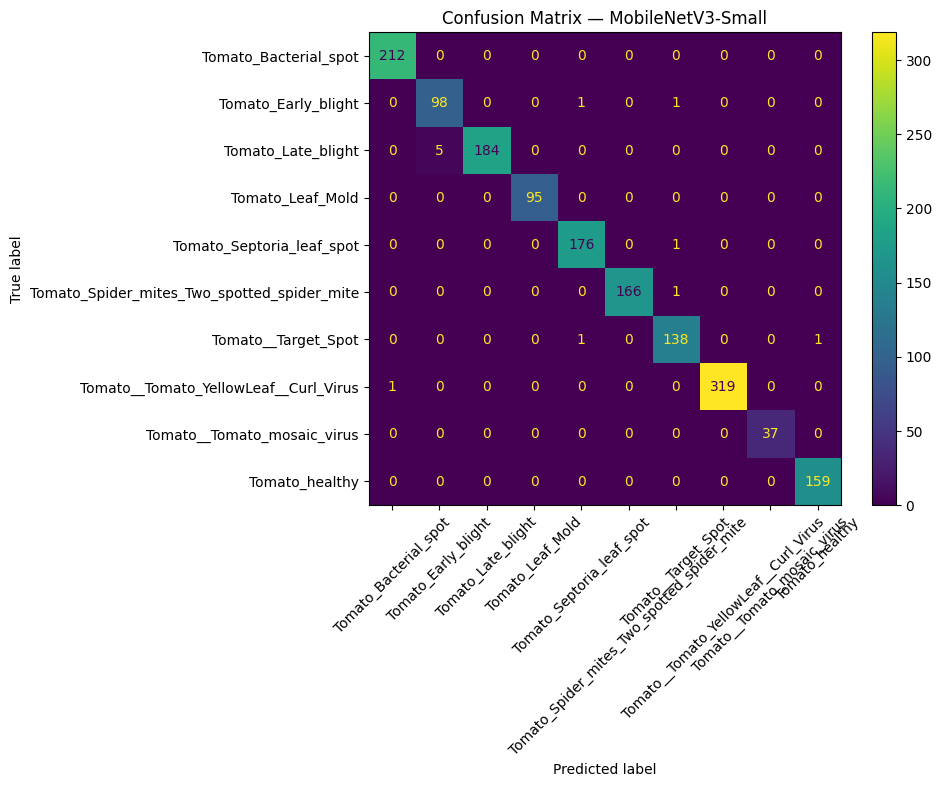

In [3]:
main()